<a href="https://colab.research.google.com/github/shruti956/fashion-mnist-classification/blob/main/fashion_mnist_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST Clothing Classification Using a Neural Network

This project builds and trains a multiclass neural network using TensorFlow and Keras to classify grayscale images of clothing into 10 categories.

The project covers image preprocessing, neural network design, model training, validation, evaluation, and analysis of classification errors.

The neural network concepts used in this project were learned through Andrew Ng's Machine Learning Specialization on Coursera and adapted to the Fashion-MNIST dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load Fashion-MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


## Dataset Exploration

The Fashion-MNIST dataset contains 28×28 grayscale images belonging to 10 different clothing categories. Each image is represented by a numerical class label from 0 to 9.

In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Number of classes:", len(class_names))
print("Pixel value range:", X_train.min(), "to", X_train.max())

Number of classes: 10
Pixel value range: 0 to 255


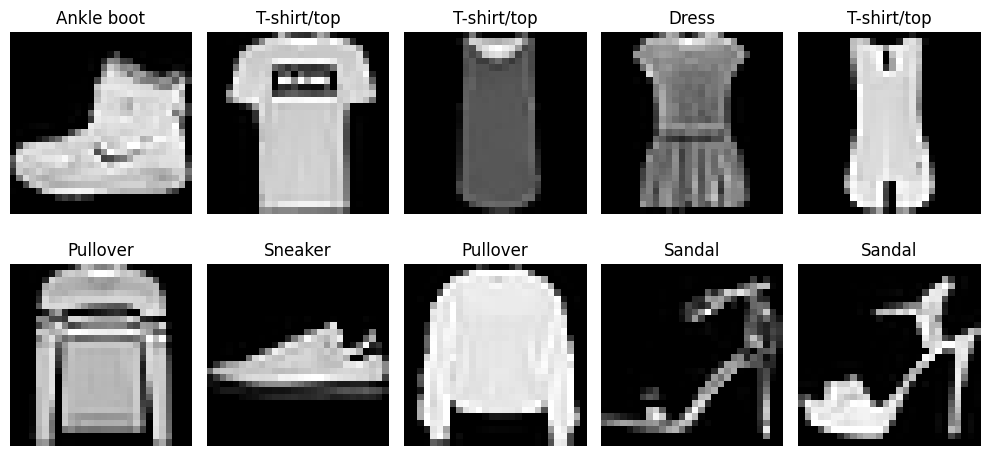

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Preprocessing

The pixel values are scaled from the original range of 0–255 to 0–1. A validation set is separated from the training data to monitor the model's performance on unseen data during training.

In [5]:
# Scale pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Use the last 10,000 training examples as validation data
X_train_final = X_train[:-10000]
y_train_final = y_train[:-10000]

X_val = X_train[-10000:]
y_val = y_train[-10000:]

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (50000, 28, 28)
Validation set: (10000, 28, 28)
Test set: (10000, 28, 28)


## Neural Network Architecture

The model uses a feedforward neural network with two hidden layers. ReLU activation is used in the hidden layers, while the output layer produces 10 logits corresponding to the 10 clothing categories.

In [6]:
tf.random.set_seed(1234)

model = Sequential([
    tf.keras.Input(shape=(28, 28)),

    Flatten(),

    Dense(128, activation="relu", name="L1"),

    Dense(64, activation="relu", name="L2"),

    Dense(10, activation="linear", name="L3")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L1 (Dense)                      │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The model is compiled using sparse categorical cross-entropy loss and the Adam optimizer. Since the output layer produces logits, the loss function is configured with `from_logits=True`.

In [7]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    metrics=["accuracy"]
)

## Model Training

The neural network is trained on the training set while its performance is monitored on the validation set.

In [8]:
history = model.fit(
    X_train_final,
    y_train_final,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8223 - loss: 0.5086 - val_accuracy: 0.8434 - val_loss: 0.4240
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8627 - loss: 0.3771 - val_accuracy: 0.8620 - val_loss: 0.3716
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8751 - loss: 0.3375 - val_accuracy: 0.8735 - val_loss: 0.3456
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8850 - loss: 0.3096 - val_accuracy: 0.8735 - val_loss: 0.3469
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8918 - loss: 0.2913 - val_accuracy: 0.8774 - val_loss: 0.3374
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8979 - loss: 0.2753 - val_accuracy: 0.8803 - val_loss: 0.3333
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9007 - loss: 0.2625 - val_accuracy: 0.8803 - val_loss: 0.3330
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9055 - loss: 0.2506 -

## Training History

Training and validation accuracy and loss are plotted across epochs to examine the model's learning progress and identify possible overfitting.

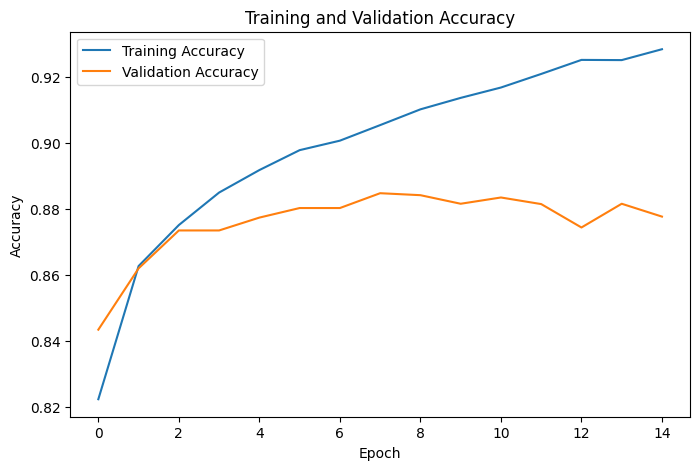

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

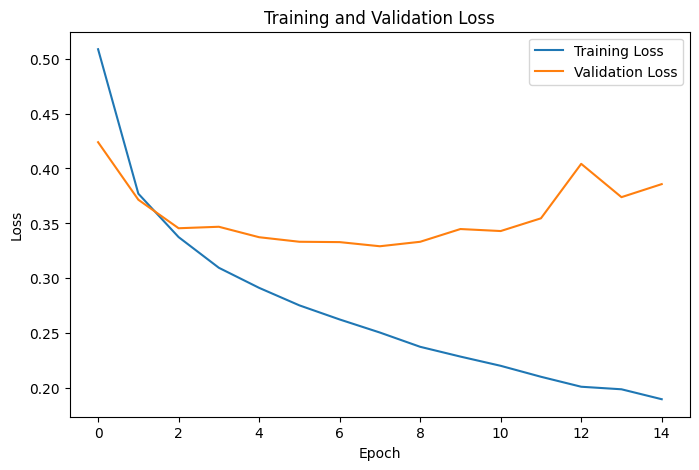

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## Test Set Evaluation

The trained model is evaluated on the unseen test set to measure its final classification performance.

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.4216
Test Accuracy: 87.11%


## Baseline Model Predictions

The baseline neural network is used to generate predictions on the test set. A confusion matrix is used to examine performance across the individual clothing categories.

In [12]:
# Get raw logits
logits = model.predict(X_test, verbose=0)

# Convert logits to probabilities
probabilities = tf.nn.softmax(logits).numpy()

# Select class with highest probability
y_pred = np.argmax(probabilities, axis=1)

print("First 10 predicted classes:", y_pred[:10])
print("First 10 actual classes:   ", y_test[:10])

First 10 predicted classes: [9 2 1 1 6 1 4 6 5 7]
First 10 actual classes:    [9 2 1 1 6 1 4 6 5 7]


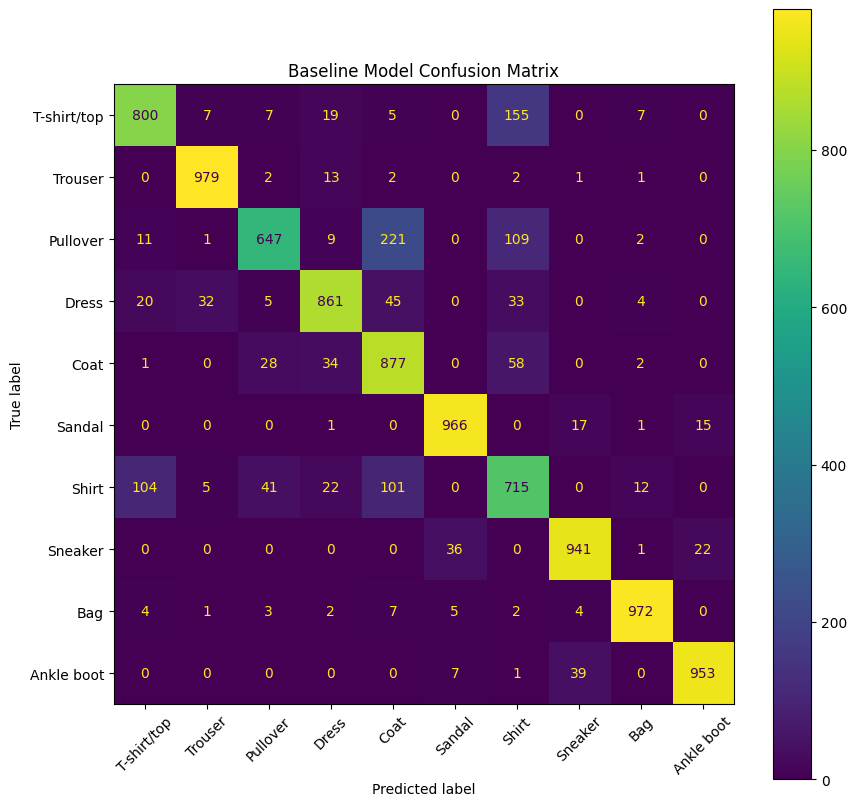

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Baseline Model Confusion Matrix")
plt.show()

## Addressing Overfitting

The baseline model showed signs of overfitting, with training performance continuing to improve while validation performance began to decline.

To address this, a second model was trained using L2 regularization and early stopping. The results of both models are compared to determine whether these techniques improve generalization.

In [14]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(1234)

improved_model = Sequential([
    tf.keras.Input(shape=(28, 28)),

    Flatten(),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dense(10, activation="linear")
])

In [15]:
improved_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    metrics=["accuracy"]
)

In [16]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [17]:
improved_history = improved_model.fit(
    X_train_final,
    y_train_final,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8166 - loss: 0.7132 - val_accuracy: 0.8448 - val_loss: 0.5617
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8493 - loss: 0.5450 - val_accuracy: 0.8518 - val_loss: 0.5199
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8568 - loss: 0.5027 - val_accuracy: 0.8596 - val_loss: 0.4924
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8620 - loss: 0.4795 - val_accuracy: 0.8531 - val_loss: 0.5016
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8658 - loss: 0.4614 - val_accuracy: 0.8537 - val_loss: 0.4916
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8694 - loss: 0.4486 - val_accuracy: 0.8543 - val_loss: 0.4863
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8706 - loss: 0.4381 - val_accuracy: 0.8532 - val_loss: 0.4892
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8729 - loss: 0.4303 - 

## Model Comparison

The regularized model with early stopping is evaluated on the test set and compared with the baseline model.

In [18]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Baseline Model")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nImproved Model")
print(f"Test Loss: {improved_test_loss:.4f}")
print(f"Test Accuracy: {improved_test_accuracy * 100:.2f}%")

Baseline Model
Test Loss: 0.4216
Test Accuracy: 87.11%

Improved Model
Test Loss: 0.4581
Test Accuracy: 86.76%


### Comparison Analysis

The baseline model achieved a test accuracy of **87.11%**, while the regularized model achieved **86.76%**.

Although L2 regularization and early stopping were introduced to address overfitting, this configuration did not improve test performance. The baseline model therefore remains the better-performing model for this experiment.

This comparison demonstrates that regularization does not automatically improve performance and that hyperparameters such as regularization strength should be tuned and evaluated experimentally.

## Analysis of Misclassified Images

To better understand the model's errors, incorrectly classified test images are displayed along with their actual and predicted classes.

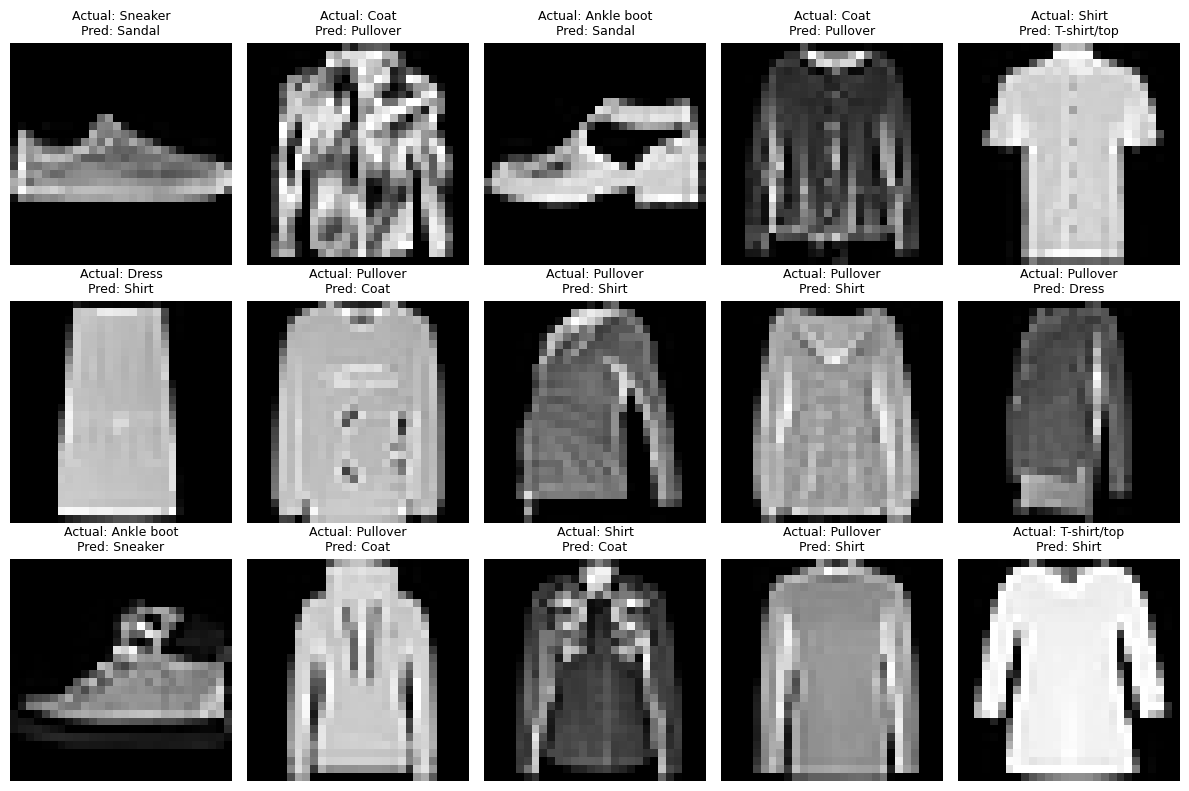

In [19]:
# Find incorrectly classified examples
incorrect_indices = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 8))

for i, index in enumerate(incorrect_indices[:15]):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test[index], cmap="gray")

    actual = class_names[y_test[index]]
    predicted = class_names[y_pred[index]]

    plt.title(
        f"Actual: {actual}\nPred: {predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Per-Class Performance

Precision, recall, and F1-score are calculated for each clothing category to identify which classes are easier or more difficult for the model to classify.

In [20]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.80      0.82      1000
     Trouser       0.96      0.98      0.97      1000
    Pullover       0.88      0.65      0.75      1000
       Dress       0.90      0.86      0.88      1000
        Coat       0.70      0.88      0.78      1000
      Sandal       0.95      0.97      0.96      1000
       Shirt       0.67      0.71      0.69      1000
     Sneaker       0.94      0.94      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



## Conclusion

This project developed a multiclass neural network using TensorFlow and Keras to classify Fashion-MNIST clothing images into 10 categories.

The project included:

- Image preprocessing and pixel normalization
- Training, validation, and test set evaluation
- A feedforward neural network with ReLU activation
- Multiclass classification using logits and softmax probabilities
- Training and validation performance analysis
- Confusion matrix and per-class evaluation
- Analysis of misclassified images
- An experiment with L2 regularization and early stopping

The baseline model achieved a test accuracy of **87.11%**. Performance varied across classes: categories such as **Trouser**, **Bag**, **Sandal**, and **Ankle boot** were classified accurately, while visually similar categories such as **Shirt**, **Pullover**, **Coat**, and **T-shirt/top** were more difficult to distinguish.

A second model using L2 regularization and early stopping achieved **86.76%** test accuracy. Since this configuration did not improve test performance, the baseline model remained the better-performing model in this experiment.

Future improvements could include hyperparameter tuning, dropout regularization, data augmentation, and convolutional neural networks (CNNs), which are better suited to preserving and learning spatial patterns in image data.